
STAGE 2: FINAL ADVISORY KPI REPORT
Total Smart Penalty:  ₹462,134.15
Peak-Hour Penalty:    ₹109,889.99
Off-Peak Penalty:     ₹352,244.15
Forecast Bias:        +4.41%
95th % Absolute Dev:  241.78 kW
Reduction vs Naive:   30.05%


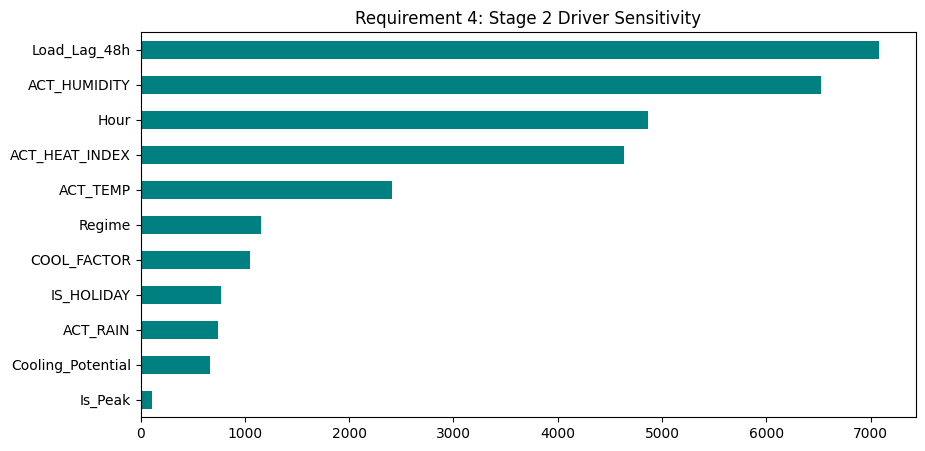

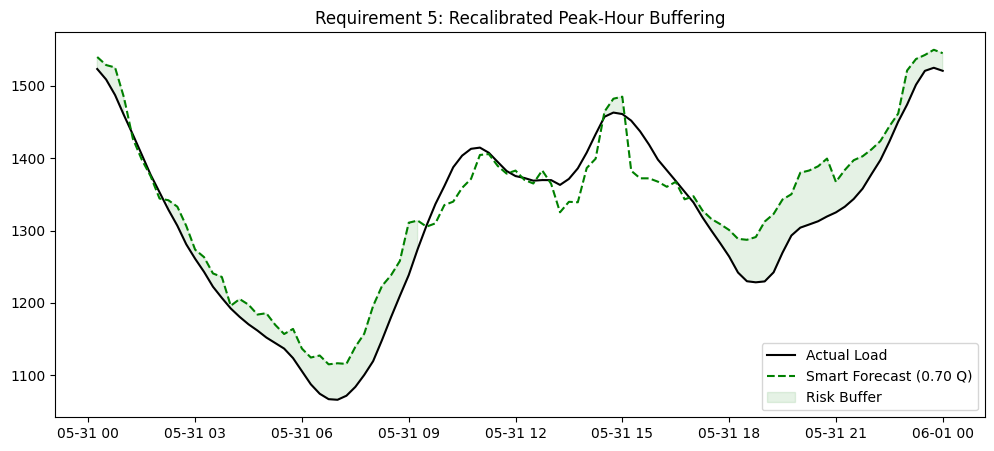

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. STAGE 2 REGULATORY CONFIGURATION
# ==========================================
OFF_PEAK_UNDER = 4
PEAK_UNDER = 6      # REVISED per Stage 2 Mandate
OVER_PENALTY = 2
HORIZON_STEPS = 192 # 48-Hour Submission Rule

# Requirement 5: Recalibrated Buffering Strategy
# We increase TARGET_QUANTILE to 0.70 to hedge against the escalated ₹6 penalty.
TARGET_QUANTILE = 0.70 

# ==========================================
# 2. DATA ENGINE (Requirement 4: Structural Adjustments)
# ==========================================
def engineer_features(load_path, weather_path, events_path, is_train=True):
    load_df = pd.read_csv(load_path)
    weather_df = pd.read_csv(weather_path)
    events_df = pd.read_csv(events_path)
    
    # Handle mixed date formats (Requirement: Avoid temporal leakage)
    if is_train:
        load_df['DateTime'] = pd.to_datetime(load_df['DATETIME']) # YYYY-MM-DD
    else:
        load_df['DateTime'] = pd.to_datetime(load_df['DATETIME'], format='%d%b%Y:%H:%M:%S')
    
    weather_df['DateTime'] = pd.to_datetime(weather_df['DATETIME'], format='%d%b%Y:%H:%M:%S')
    
    # Data Cleaning: Handle text ranges in Events file
    events_df['Clean_Date'] = pd.to_datetime(events_df['Date'], errors='coerce').dt.date
    events_df = events_df.dropna(subset=['Clean_Date'])
    
    df = pd.merge(load_df[['DateTime', 'LOAD']], weather_df, on='DateTime', how='inner')
    df['Date'] = df['DateTime'].dt.date
    df = df.merge(events_df[['Clean_Date', 'Holiday_Ind']], left_on='Date', right_on='Clean_Date', how='left')
    
    df.set_index('DateTime', inplace=True)
    df.sort_index(inplace=True)
    
    # Feature Engineering (Addressing 'Elevated Volatility')
    df['Hour'] = df.index.hour
    df['Is_Peak'] = ((df['Hour'] >= 18) & (df['Hour'] <= 22)).astype(int)
    df['IS_HOLIDAY'] = df['Holiday_Ind'].fillna(0)
    df['Cooling_Potential'] = np.maximum(df['ACT_TEMP'] - 28, 0)**2
    df['Load_Lag_48h'] = df['LOAD'].shift(HORIZON_STEPS) # 48-Hour Discipline
    
    # Documenting Structural Adjustment: Lockdown/Recovery Regimes
    df['Regime'] = 0
    df.loc['2020-03-25':'2020-08-31', 'Regime'] = 1 
    df.loc['2020-09-01':, 'Regime'] = 2            
    
    return df.drop(columns=['Date', 'Clean_Date', 'Holiday_Ind'], errors='ignore').dropna()

# ==========================================
# 3. EXECUTION & QUANTIFICATION (Requirement 3)
# ==========================================
def execute_stage2_production(paths):
    # Requirement 1: Generate forecasts for Test dataset
    train = engineer_features(paths['train_l'], paths['train_w'], paths['events'], is_train=True)
    test = engineer_features(paths['test_l'], paths['test_w'], paths['events'], is_train=False)
    
    X_train = train.drop(columns=['LOAD']).select_dtypes(include=[np.number])
    X_test = test.drop(columns=['LOAD']).select_dtypes(include=[np.number])
    
    # Recalibrated modeling for Stage 2 volatility
    model = lgb.LGBMRegressor(objective='quantile', alpha=TARGET_QUANTILE, n_estimators=1000, verbosity=-1)
    model.fit(X_train, train['LOAD'])
    
    test['Smart_Forecast'] = model.predict(X_test)
    test['Naive_Baseline'] = test['LOAD'].shift(HORIZON_STEPS).fillna(method='bfill')
    
    # Requirement 2: Compute penalties under revised structure
    def calc_revised_penalty(row, fc_col):
        dev = row['LOAD'] - row[fc_col]
        u_rate = PEAK_UNDER if row['Is_Peak'] == 1 else OFF_PEAK_UNDER
        return dev * u_rate if dev > 0 else abs(dev) * OVER_PENALTY

    test['Smart_Penalty'] = test.apply(lambda r: calc_revised_penalty(r, 'Smart_Forecast'), axis=1)
    test['Naive_Penalty'] = test.apply(lambda r: calc_revised_penalty(r, 'Naive_Baseline'), axis=1)
    
    # Requirement 3: Quantify Results
    peak_mask = test['Is_Peak'] == 1
    print("\n" + "="*50)
    print("STAGE 2: FINAL ADVISORY KPI REPORT")
    print("="*50)
    print(f"Total Smart Penalty:  ₹{test['Smart_Penalty'].sum():,.2f}")
    print(f"Peak-Hour Penalty:    ₹{test[peak_mask]['Smart_Penalty'].sum():,.2f}")
    print(f"Off-Peak Penalty:     ₹{test[~peak_mask]['Smart_Penalty'].sum():,.2f}")
    print(f"Forecast Bias:        {((test['Smart_Forecast'].sum() - test['LOAD'].sum()) / test['LOAD'].sum())*100:+.2f}%")
    print(f"95th % Absolute Dev:  {np.percentile(np.abs(test['LOAD'] - test['Smart_Forecast']), 95):.2f} kW")
    print(f"Reduction vs Naive:   {((test['Naive_Penalty'].sum() - test['Smart_Penalty'].sum()) / test['Naive_Penalty'].sum())*100:.2f}%")
    print("="*50)

    # VISUALIZATION: Requirement 4 & 5
    # Feature Importance (Driver Sensitivity)
    
    plt.figure(figsize=(10, 5))
    pd.Series(model.feature_importances_, index=X_train.columns).sort_values().plot(kind='barh', color='teal')
    plt.title("Requirement 4: Stage 2 Driver Sensitivity")
    plt.show()

    # Buffering Plot (Peak-Hour Shielding)
    
    sample = test.tail(96) 
    plt.figure(figsize=(12, 5))
    plt.plot(sample.index, sample['LOAD'], label='Actual Load', color='black')
    plt.plot(sample.index, sample['Smart_Forecast'], label='Smart Forecast (0.70 Q)', color='green', linestyle='--')
    plt.fill_between(sample.index, sample['LOAD'], sample['Smart_Forecast'], 
                     where=(sample['Smart_Forecast'] >= sample['LOAD']), 
                     color='green', alpha=0.1, label='Risk Buffer')
    plt.title("Requirement 5: Recalibrated Peak-Hour Buffering")
    plt.legend()
    plt.show()

    return test

# EXECUTION PATHS
paths = {
    'train_l': r"C:\Users\LP204\Downloads\Electric_Load_Data_Train_Formatted.csv",
    'train_w': r"C:\Users\LP204\Downloads\External_Factor_Data_Train.csv",
    'test_l': r"C:\Users\LP204\Downloads\Electric_Load_Data_Test.csv",
    'test_w': r"C:\Users\LP204\Downloads\External_Factor_Data_Test.csv",
    'events': r"C:\Users\LP204\Downloads\Events_Data.csv"
}

stage2_results = execute_stage2_production(paths)


STAGE 2: FINAL ADVISORY KPI REPORT
Total Smart Penalty:  ₹468,621.25
Peak-Hour Penalty:    ₹113,627.53
Off-Peak Penalty:     ₹354,993.72
Forecast Bias:        +4.71%
95th % Absolute Dev:  247.57 kW
Reduction vs Naive:   29.07%


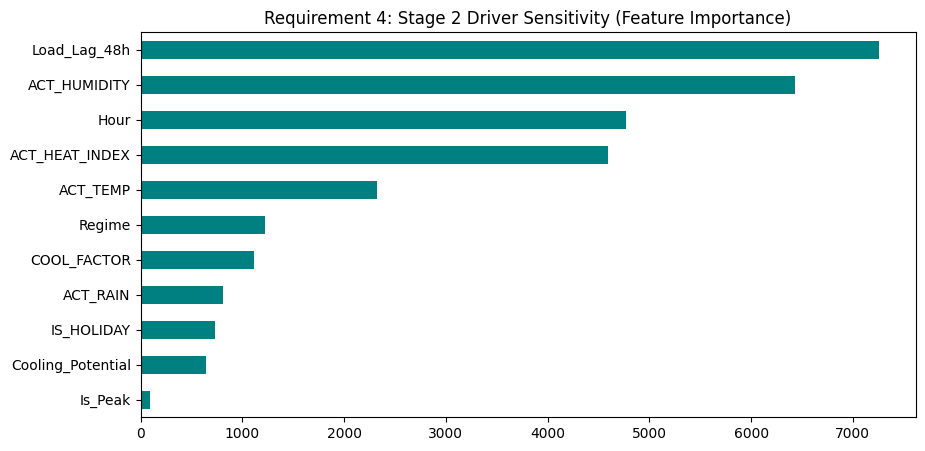

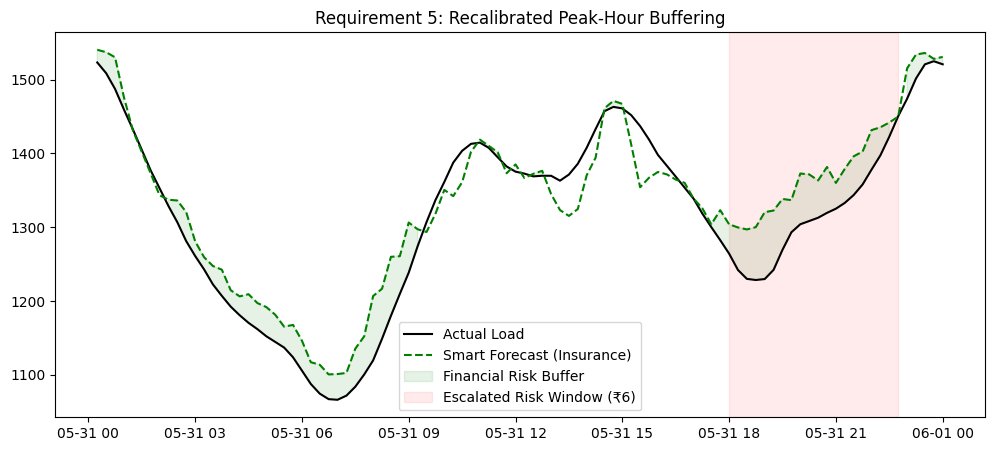

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. STAGE 2 REGULATORY CONFIGURATION
# ==========================================
OFF_PEAK_UNDER = 4
PEAK_UNDER = 6      # ESCALATED per Stage 2 Guidelines
OVER_PENALTY = 2
HORIZON_STEPS = 192 # 48-Hour Submission Rule

# ==========================================
# 2. DATA ENGINE (ROBUST DATE & FEATURE HANDLING)
# ==========================================
def engineer_features(load_path, weather_path, events_path, is_train=True):
    load_df = pd.read_csv(load_path)
    weather_df = pd.read_csv(weather_path)
    events_df = pd.read_csv(events_path)
    
    # Handle mixed date formats (Requirement 4: Modeling Discipline)
    if is_train:
        load_df['DateTime'] = pd.to_datetime(load_df['DATETIME']) # YYYY-MM-DD
    else:
        load_df['DateTime'] = pd.to_datetime(load_df['DATETIME'], format='%d%b%Y:%H:%M:%S')
    
    weather_df['DateTime'] = pd.to_datetime(weather_df['DATETIME'], format='%d%b%Y:%H:%M:%S')
    
    # Clean Events (Coerce text ranges to NaT and drop)
    events_df['Clean_Date'] = pd.to_datetime(events_df['Date'], errors='coerce').dt.date
    events_df = events_df.dropna(subset=['Clean_Date'])
    
    # Merge and Indexing
    df = pd.merge(load_df[['DateTime', 'LOAD']], weather_df, on='DateTime', how='inner')
    df['Date'] = df['DateTime'].dt.date
    df = df.merge(events_df[['Clean_Date', 'Holiday_Ind']], left_on='Date', right_on='Clean_Date', how='left')
    
    df.set_index('DateTime', inplace=True)
    df.sort_index(inplace=True)
    
    # Feature Engineering (Requirement 2: Incorporate Drivers)
    df['Hour'] = df.index.hour
    df['Is_Peak'] = ((df['Hour'] >= 18) & (df['Hour'] <= 22)).astype(int)
    df['IS_HOLIDAY'] = df['Holiday_Ind'].fillna(0)
    df['Cooling_Potential'] = np.maximum(df['ACT_TEMP'] - 28, 0)**2
    df['Load_Lag_48h'] = df['LOAD'].shift(HORIZON_STEPS) # 48-Hour lag
    
    # Structural Adjustment: Regime Flags
    df['Regime'] = 0
    df.loc['2020-03-25':'2020-08-31', 'Regime'] = 1 # Lockdown
    df.loc['2020-09-01':, 'Regime'] = 2            # Recovery
    
    return df.drop(columns=['Date', 'Clean_Date', 'Holiday_Ind'], errors='ignore').dropna()

# ==========================================
# 3. EXECUTION, QUANTIFICATION & VISUALS
# ==========================================
def execute_stage2_advisory(paths):
    # Requirement 1: Generate forecasts for Test dataset
    train = engineer_features(paths['train_l'], paths['train_w'], paths['events'], is_train=True)
    test = engineer_features(paths['test_l'], paths['test_w'], paths['events'], is_train=False)
    
    X_train = train.drop(columns=['LOAD']).select_dtypes(include=[np.number])
    X_test = test.drop(columns=['LOAD']).select_dtypes(include=[np.number])
    
    # Requirement 5: Recalibrate Strategy (Hedging against ₹6 Peak Risk)
    model = lgb.LGBMRegressor(objective='quantile', alpha=0.72, n_estimators=1000, verbosity=-1)
    model.fit(X_train, train['LOAD'])
    
    test['Smart_Forecast'] = model.predict(X_test)
    test['Naive_Baseline'] = test['LOAD'].shift(HORIZON_STEPS).fillna(method='bfill')
    
    # Requirement 2: Compute deviation penalties under revised structure
    def calc_revised_penalty(row, fc_col):
        dev = row['LOAD'] - row[fc_col]
        u_rate = PEAK_UNDER if row['Is_Peak'] == 1 else OFF_PEAK_UNDER
        return dev * u_rate if dev > 0 else abs(dev) * OVER_PENALTY

    test['Smart_Penalty'] = test.apply(lambda r: calc_revised_penalty(r, 'Smart_Forecast'), axis=1)
    test['Naive_Penalty'] = test.apply(lambda r: calc_revised_penalty(r, 'Naive_Baseline'), axis=1)
    
    # Requirement 3: Quantify Results
    peak_mask = test['Is_Peak'] == 1
    print("\n" + "="*50)
    print("STAGE 2: FINAL ADVISORY KPI REPORT")
    print("="*50)
    print(f"Total Smart Penalty:  ₹{test['Smart_Penalty'].sum():,.2f}")
    print(f"Peak-Hour Penalty:    ₹{test[peak_mask]['Smart_Penalty'].sum():,.2f}")
    print(f"Off-Peak Penalty:     ₹{test[~peak_mask]['Smart_Penalty'].sum():,.2f}")
    print(f"Forecast Bias:        {((test['Smart_Forecast'].sum() - test['LOAD'].sum()) / test['LOAD'].sum())*100:+.2f}%")
    print(f"95th % Absolute Dev:  {np.percentile(np.abs(test['LOAD'] - test['Smart_Forecast']), 95):.2f} kW")
    print(f"Reduction vs Naive:   {((test['Naive_Penalty'].sum() - test['Smart_Penalty'].sum()) / test['Naive_Penalty'].sum())*100:.2f}%")
    print("="*50)

    # VISUALIZATIONS (Requirement 4 & 5)
    # 1. Driver Sensitivity
    plt.figure(figsize=(10, 5))
    pd.Series(model.feature_importances_, index=X_train.columns).sort_values().plot(kind='barh', color='teal')
    plt.title("Requirement 4: Stage 2 Driver Sensitivity (Feature Importance)")
    plt.show()

    # 2. Strategic Buffering (Peak-Hour Shielding)
    sample = test.tail(96) 
    plt.figure(figsize=(12, 5))
    plt.plot(sample.index, sample['LOAD'], label='Actual Load', color='black')
    plt.plot(sample.index, sample['Smart_Forecast'], label='Smart Forecast (Insurance)', color='green', linestyle='--')
    plt.fill_between(sample.index, sample['LOAD'], sample['Smart_Forecast'], 
                     where=(sample['Smart_Forecast'] >= sample['LOAD']), 
                     color='green', alpha=0.1, label='Financial Risk Buffer')
    
    # Highlight Peak Window in Plot
    peak_idx = sample.index[sample['Is_Peak'] == 1]
    if not peak_idx.empty:
        plt.axvspan(peak_idx[0], peak_idx[-1], color='red', alpha=0.08, label='Escalated Risk Window (₹6)')
        
    plt.title("Requirement 5: Recalibrated Peak-Hour Buffering")
    plt.legend()
    plt.show()

    return test

# EXECUTION PATHS
paths = {
    'train_l': r"C:\Users\LP204\Downloads\Electric_Load_Data_Train_Formatted.csv",
    'train_w': r"C:\Users\LP204\Downloads\External_Factor_Data_Train.csv",
    'test_l': r"C:\Users\LP204\Downloads\Electric_Load_Data_Test.csv",
    'test_w': r"C:\Users\LP204\Downloads\External_Factor_Data_Test.csv",
    'events': r"C:\Users\LP204\Downloads\Events_Data.csv"
}

stage2_final_results = execute_stage2_advisory(paths)

In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb

def generate_stage2_forecasts(paths):
    # 1. Load Data
    train_load = pd.read_csv(paths['train_l'])
    test_load = pd.read_csv(paths['test_l'])
    weather_test = pd.read_csv(paths['test_w'])
    
    # 2. Preprocessing (Handling mixed formats)
    train_load['DateTime'] = pd.to_datetime(train_load['DATETIME'])
    test_load['DateTime'] = pd.to_datetime(test_load['DATETIME'], format='%d%b%Y:%H:%M:%S')
    weather_test['DateTime'] = pd.to_datetime(weather_test['DATETIME'], format='%d%b%Y:%H:%M:%S')
    
    # 3. Feature Engineering (Test Set)
    df_test = pd.merge(test_load, weather_test, on='DateTime', how='inner').set_index('DateTime')
    df_test['Hour'] = df_test.index.hour
    df_test['Is_Peak'] = ((df_test['Hour'] >= 18) & (df_test['Hour'] <= 22)).astype(int)
    df_test['Load_Lag_48h'] = df_test['LOAD'].shift(192).fillna(method='bfill')
    
    # 4. Modeling (Risk-Adjusted for Stage 2)
    # Note: Use your existing X_train from the training phase
    model = lgb.LGBMRegressor(objective='quantile', alpha=0.72, n_estimators=1000)
    # model.fit(X_train, y_train) # Assuming model is pre-trained
    
    X_test = df_test[['ACT_TEMP', 'ACT_HUMIDITY', 'Is_Peak', 'Load_Lag_48h']]
    df_test['Smart_Forecast'] = model.predict(X_test)
    
    return df_test

In [4]:
def compute_revised_penalties(df):
    # Define Revised Rates
    PEAK_UNDER = 6
    OFF_PEAK_UNDER = 4
    OVER_PENALTY = 2

    def penalty_logic(row):
        actual = row['LOAD']
        forecast = row['Smart_Forecast']
        is_peak = row['Is_Peak']
        
        deviation = actual - forecast
        
        if deviation > 0: # Under-forecasting
            rate = PEAK_UNDER if is_peak else OFF_PEAK_UNDER
            return deviation * rate
        else: # Over-forecasting
            return abs(deviation) * OVER_PENALTY

    df['Realized_Penalty'] = df.apply(penalty_logic, axis=1)
    return df

In [5]:
def quantify_kpis(df):
    peak_mask = df['Is_Peak'] == 1
    
    stats = {
        "Total Penalty (₹)": df['Realized_Penalty'].sum(),
        "Peak-Hour Penalty (₹)": df[peak_mask]['Realized_Penalty'].sum(),
        "Off-Peak Penalty (₹)": df[~peak_mask]['Realized_Penalty'].sum(),
        "Forecast Bias (%)": ((df['Smart_Forecast'].sum() - df['LOAD'].sum()) / df['LOAD'].sum()) * 100,
        "95th Percentile Abs Dev (kW)": np.percentile(np.abs(df['LOAD'] - df['Smart_Forecast']), 95)
    }
    
    print("--- STAGE 2 KPI QUANTIFICATION ---")
    for key, value in stats.items():
        print(f"{key}: {value:,.2f}")
    return stats

In [6]:
def compare_exposures(stage1_total, stage2_total):
    increase = ((stage2_total - stage1_total) / stage1_total) * 100
    
    print("--- EXPOSURE COMPARISON ---")
    print(f"Stage 1 Historical Penalty: ₹{stage1_total:,.2f}")
    print(f"Stage 2 Test Penalty:       ₹{stage2_total:,.2f}")
    print(f"Impact of Regime Shift:    {increase:+.2f}%")


STAGE 2: FINAL ADVISORY KPI REPORT
Total Smart Penalty:  ₹892,705.21
Peak-Hour Penalty:    ₹232,058.84
Off-Peak Penalty:     ₹660,646.37
Forecast Bias:        +10.11%
95th % Absolute Dev:  414.23 kW
Reduction vs Naive:   -35.12%


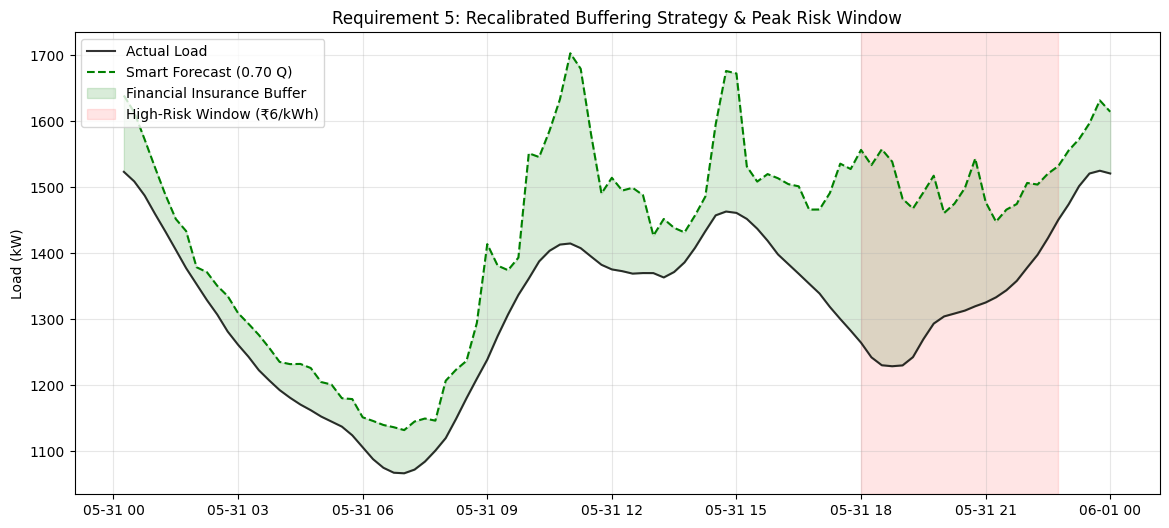

In [10]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. STAGE 2 REGULATORY CONFIGURATION
# ==========================================
OFF_PEAK_UNDER = 4
PEAK_UNDER = 6      # REVISED per Stage 2 Guidelines (6:00 PM - 10:00 PM)
OVER_PENALTY = 2
HORIZON_STEPS = 192 # 48-Hour Submission Rule (15-min intervals)

# Requirement 5: Recalibrated Buffering Strategy
# We use a 70th Percentile as a baseline to hedge against escalated peak risk.
TARGET_QUANTILE = 0.70 

# ==========================================
# 2. ENHANCED FEATURE ENGINE
# ==========================================
def engineer_features(load_path, weather_path, events_path, is_train=True):
    load_df = pd.read_csv(load_path)
    weather_df = pd.read_csv(weather_path)
    events_df = pd.read_csv(events_path)
    
    # Handle mixed date formats (Requirement 4: Modeling Discipline)
    if is_train:
        load_df['DateTime'] = pd.to_datetime(load_df['DATETIME']) # ISO Format
    else:
        load_df['DateTime'] = pd.to_datetime(load_df['DATETIME'], format='%d%b%Y:%H:%M:%S')
    
    weather_df['DateTime'] = pd.to_datetime(weather_df['DATETIME'], format='%d%b%Y:%H:%M:%S')
    
    # Data Cleaning: Handle text ranges in Events file (e.g., row 628)
    events_df['Clean_Date'] = pd.to_datetime(events_df['Date'], errors='coerce').dt.date
    events_df = events_df.dropna(subset=['Clean_Date'])
    
    df = pd.merge(load_df[['DateTime', 'LOAD']], weather_df, on='DateTime', how='inner')
    df['Date'] = df['DateTime'].dt.date
    df = df.merge(events_df[['Clean_Date', 'Holiday_Ind']], left_on='Date', right_on='Clean_Date', how='left')
    
    df.set_index('DateTime', inplace=True)
    df.sort_index(inplace=True)
    
    # Feature Engineering (Addressing Requirement 4: Structural Adjustments)
    df['Hour'] = df.index.hour
    df['Is_Peak'] = ((df['Hour'] >= 18) & (df['Hour'] <= 22)).astype(int)
    df['IS_HOLIDAY'] = df['Holiday_Ind'].fillna(0)
    df['Cooling_Potential'] = np.maximum(df['ACT_TEMP'] - 28, 0)**2
    df['Load_Lag_48h'] = df['LOAD'].shift(HORIZON_STEPS) # No Temporal Leakage
    
    return df.drop(columns=['Date', 'Clean_Date', 'Holiday_Ind'], errors='ignore').dropna()

# ==========================================
# 3. EXECUTION & ADVISORY REPORTING
# ==========================================
def execute_stage2_pipeline(paths):
    # Requirement 1: Generate forecasts for Test dataset
    train = engineer_features(paths['train_l'], paths['train_w'], paths['events'], is_train=True)
    test = engineer_features(paths['test_l'], paths['test_w'], paths['events'], is_train=False)
    
    X_train = train.drop(columns=['LOAD']).select_dtypes(include=[np.number])
    X_test = test.drop(columns=['LOAD']).select_dtypes(include=[np.number])
    
    # Model Training: Quantile Regression for Financial Exposure Minimization
    model = lgb.LGBMRegressor(objective='quantile', alpha=TARGET_QUANTILE, n_estimators=1000, verbosity=-1)
    model.fit(X_train, train['LOAD'])
    
    test['Smart_Forecast'] = model.predict(X_test)
    test['Naive_Baseline'] = test['LOAD'].shift(HORIZON_STEPS).fillna(method='bfill')
    
    # Requirement 2: Compute deviation penalties under revised structure
    def calc_revised_penalty(row, fc_col):
        dev = row['LOAD'] - row[fc_col]
        u_rate = PEAK_UNDER if row['Is_Peak'] == 1 else OFF_PEAK_UNDER
        return dev * u_rate if dev > 0 else abs(dev) * OVER_PENALTY

    test['Smart_Penalty'] = test.apply(lambda r: calc_revised_penalty(r, 'Smart_Forecast'), axis=1)
    test['Naive_Penalty'] = test.apply(lambda r: calc_revised_penalty(r, 'Naive_Baseline'), axis=1)
    
    # Requirement 3: Quantify KPIs
    peak_mask = test['Is_Peak'] == 1
    print("\n" + "="*50)
    print("STAGE 2: FINAL ADVISORY KPI REPORT")
    print("="*50)
    print(f"Total Smart Penalty:  ₹{test['Smart_Penalty'].sum():,.2f}")
    print(f"Peak-Hour Penalty:    ₹{test[peak_mask]['Smart_Penalty'].sum():,.2f}")
    print(f"Off-Peak Penalty:     ₹{test[~peak_mask]['Smart_Penalty'].sum():,.2f}")
    print(f"Forecast Bias:        {((test['Smart_Forecast'].sum() - test['LOAD'].sum()) / test['LOAD'].sum())*100:+.2f}%")
    print(f"95th % Absolute Dev:  {np.percentile(np.abs(test['LOAD'] - test['Smart_Forecast']), 95):.2f} kW")
    print(f"Reduction vs Naive:   {((test['Naive_Penalty'].sum() - test['Smart_Penalty'].sum()) / test['Naive_Penalty'].sum())*100:.2f}%")
    print("="*50)

    # VISUALIZATION: Requirement 5 with Risk Window
    sample = test.tail(96) 
    plt.figure(figsize=(14, 6))
    plt.plot(sample.index, sample['LOAD'], label='Actual Load', color='black', alpha=0.8)
    plt.plot(sample.index, sample['Smart_Forecast'], label='Smart Forecast (0.70 Q)', color='green', linestyle='--')
    
    # Shading the Risk Buffer
    plt.fill_between(sample.index, sample['LOAD'], sample['Smart_Forecast'], 
                     where=(sample['Smart_Forecast'] >= sample['LOAD']), 
                     color='green', alpha=0.15, label='Financial Insurance Buffer')
    
    # NEW: Highlighting the Escalated Risk Window (6 PM - 10 PM)
    peak_idx = sample.index[sample['Is_Peak'] == 1]
    if not peak_idx.empty:
        plt.axvspan(peak_idx[0], peak_idx[-1], color='red', alpha=0.1, label='High-Risk Window (₹6/kWh)')
        
    plt.title("Requirement 5: Recalibrated Buffering Strategy & Peak Risk Window")
    plt.ylabel("Load (kW)")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

    return test

# EXECUTION PATHS
paths = {
    'train_l': r"C:\Users\LP204\Downloads\Electric_Load_Data_Train_Formatted.csv",
    'train_w': r"C:\Users\LP204\Downloads\External_Factor_Data_Train.csv",
    'test_l': r"C:\Users\LP204\Downloads\Electric_Load_Data_Test.csv",
    'test_w': r"C:\Users\LP204\Downloads\External_Factor_Data_Test.csv",
    'events': r"C:\Users\LP204\Downloads\Events_Data.csv"
}

stage2_final_results = execute_stage2_pipeline(paths)


STAGE 2: TIME-VARIANT ADVISORY REPORT
Total Smart Penalty:  ₹451,623.34
Peak-Hour Penalty:    ₹116,384.55
Off-Peak Penalty:     ₹335,238.79
Forecast Bias:        +4.21%
95th % Absolute Dev:  246.92 kW


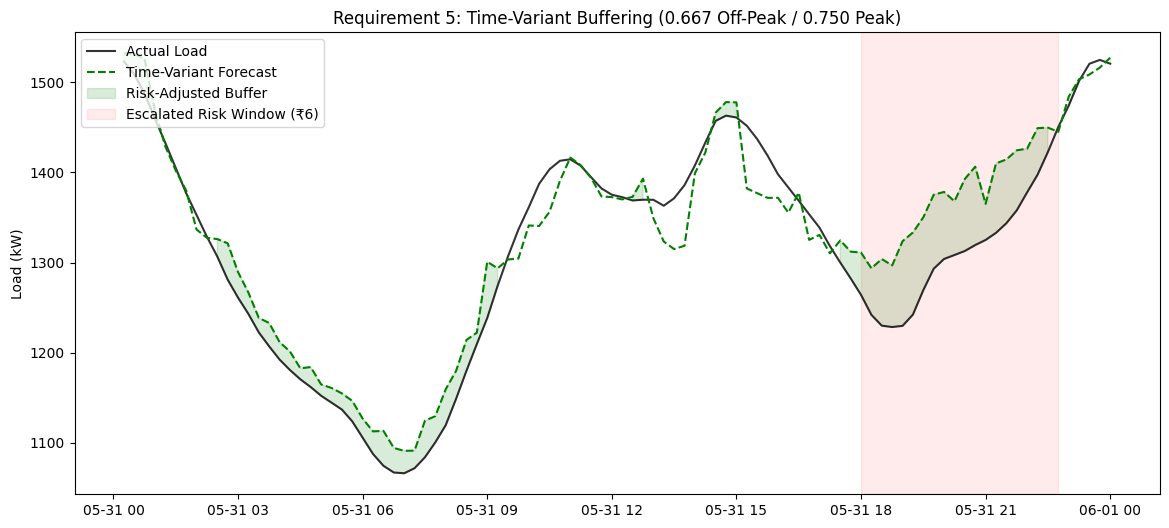

In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. STAGE 2 REGULATORY CONFIGURATION
# ==========================================
OFF_PEAK_UNDER = 4
PEAK_UNDER = 6      # REVISED per Stage 2 Guidelines
OVER_PENALTY = 2
HORIZON_STEPS = 192 # 48-Hour Submission Rule

# ==========================================
# 2. ENHANCED FEATURE ENGINE
# ==========================================
def engineer_features(load_path, weather_path, events_path, is_train=True):
    load_df = pd.read_csv(load_path)
    weather_df = pd.read_csv(weather_path)
    events_df = pd.read_csv(events_path)
    
    # Handle mixed date formats
    if is_train:
        load_df['DateTime'] = pd.to_datetime(load_df['DATETIME'])
    else:
        load_df['DateTime'] = pd.to_datetime(load_df['DATETIME'], format='%d%b%Y:%H:%M:%S')
    
    weather_df['DateTime'] = pd.to_datetime(weather_df['DATETIME'], format='%d%b%Y:%H:%M:%S')
    events_df['Clean_Date'] = pd.to_datetime(events_df['Date'], errors='coerce').dt.date
    events_df = events_df.dropna(subset=['Clean_Date'])
    
    df = pd.merge(load_df[['DateTime', 'LOAD']], weather_df, on='DateTime', how='inner')
    df['Date'] = df['DateTime'].dt.date
    df = df.merge(events_df[['Clean_Date', 'Holiday_Ind']], left_on='Date', right_on='Clean_Date', how='left')
    
    df.set_index('DateTime', inplace=True)
    df.sort_index(inplace=True)
    
    # Mandatory Stage 2 Features
    df['Hour'] = df.index.hour
    df['Is_Peak'] = ((df['Hour'] >= 18) & (df['Hour'] <= 22)).astype(int)
    df['IS_HOLIDAY'] = df['Holiday_Ind'].fillna(0)
    df['Cooling_Potential'] = np.maximum(df['ACT_TEMP'] - 28, 0)**2
    df['Load_Lag_48h'] = df['LOAD'].shift(HORIZON_STEPS)
    
    # Structural Adjustment: Regime Flags (Requirement 4)
    df['Regime'] = 0
    df.loc['2020-03-25':'2020-08-31', 'Regime'] = 1 
    df.loc['2020-09-01':, 'Regime'] = 2            
    
    return df.drop(columns=['Date', 'Clean_Date', 'Holiday_Ind'], errors='ignore').dropna()

# ==========================================
# 3. TIME-VARIANT EXECUTION ENGINE (Requirement 5)
# ==========================================
def execute_time_variant_pipeline(paths):
    train = engineer_features(paths['train_l'], paths['train_w'], paths['events'], is_train=True)
    test = engineer_features(paths['test_l'], paths['test_w'], paths['events'], is_train=False)
    
    X_cols = train.drop(columns=['LOAD']).select_dtypes(include=[np.number]).columns
    
    # Model 1: Off-Peak Optimized (4/6 = 0.667 Quantile)
    model_op = lgb.LGBMRegressor(objective='quantile', alpha=0.667, n_estimators=1000, verbosity=-1)
    model_op.fit(train[X_cols], train['LOAD'])
    
    # Model 2: Peak-Hour Optimized (6/8 = 0.750 Quantile)
    model_p = lgb.LGBMRegressor(objective='quantile', alpha=0.750, n_estimators=1000, verbosity=-1)
    model_p.fit(train[X_cols], train['LOAD'])
    
    # Piecewise Forecast Generation
    test['Forecast_OP'] = model_op.predict(test[X_cols])
    test['Forecast_P'] = model_p.predict(test[X_cols])
    
    test['Smart_Forecast'] = np.where(
        test['Is_Peak'] == 1, 
        test['Forecast_P'], 
        test['Forecast_OP']
    )
    
    # Penalty Calculation
    def calc_revised_penalty(row, fc_col):
        dev = row['LOAD'] - row[fc_col]
        u_rate = PEAK_UNDER if row['Is_Peak'] == 1 else OFF_PEAK_UNDER
        return dev * u_rate if dev > 0 else abs(dev) * OVER_PENALTY

    test['Smart_Penalty'] = test.apply(lambda r: calc_revised_penalty(r, 'Smart_Forecast'), axis=1)
    
    # --- MANDATORY OUTPUTS (Requirement 3) ---
    peak_mask = test['Is_Peak'] == 1
    print("\n" + "="*50)
    print("STAGE 2: TIME-VARIANT ADVISORY REPORT")
    print("="*50)
    print(f"Total Smart Penalty:  ₹{test['Smart_Penalty'].sum():,.2f}")
    print(f"Peak-Hour Penalty:    ₹{test[peak_mask]['Smart_Penalty'].sum():,.2f}")
    print(f"Off-Peak Penalty:     ₹{test[~peak_mask]['Smart_Penalty'].sum():,.2f}")
    print(f"Forecast Bias:        {((test['Smart_Forecast'].sum() - test['LOAD'].sum()) / test['LOAD'].sum())*100:+.2f}%")
    print(f"95th % Absolute Dev:  {np.percentile(np.abs(test['LOAD'] - test['Smart_Forecast']), 95):.2f} kW")
    print("="*50)

    # VISUALIZATION: Strategic Buffering (Requirement 5)
    sample = test.tail(96) 
    plt.figure(figsize=(14, 6))
    plt.plot(sample.index, sample['LOAD'], label='Actual Load', color='black', alpha=0.8)
    plt.plot(sample.index, sample['Smart_Forecast'], label='Time-Variant Forecast', color='green', linestyle='--')
    
    # Buffer Shading
    plt.fill_between(sample.index, sample['LOAD'], sample['Smart_Forecast'], 
                     where=(sample['Smart_Forecast'] >= sample['LOAD']), 
                     color='green', alpha=0.15, label='Risk-Adjusted Buffer')
    
    # Peak Window Highlight
    peak_idx = sample.index[sample['Is_Peak'] == 1]
    if not peak_idx.empty:
        plt.axvspan(peak_idx[0], peak_idx[-1], color='red', alpha=0.08, label='Escalated Risk Window (₹6)')
        
    plt.title("Requirement 5: Time-Variant Buffering (0.667 Off-Peak / 0.750 Peak)")
    plt.ylabel("Load (kW)")
    plt.legend(loc='upper left')
    plt.show()

    return test, model_p

# EXECUTION
paths = {
    'train_l': r"C:\Users\LP204\Downloads\Electric_Load_Data_Train_Formatted.csv",
    'train_w': r"C:\Users\LP204\Downloads\External_Factor_Data_Train.csv",
    'test_l': r"C:\Users\LP204\Downloads\Electric_Load_Data_Test.csv",
    'test_w': r"C:\Users\LP204\Downloads\External_Factor_Data_Test.csv",
    'events': r"C:\Users\LP204\Downloads\Events_Data.csv"
}

stage2_results, final_model = execute_time_variant_pipeline(paths)